In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
plt.close('all')

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# make string list in column job_skills into panda series (list) object
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

* show which companies are most hiring in the UK
* percentage of jobs are wfh
* breakdown of the top 5 jobs
* salary year average of data jobs
* monthly demand for jobs

# show which companies are most hiring in the UK

In [7]:
df_UK = df[df["job_country"] == "United Kingdom"].copy()

In [14]:
df_companies = df_UK.groupby("company_name").size()

df_companies = df_companies.reset_index(name="count")

df_companies.sort_values(by="count", ascending=False, inplace=True)

df_companies

,company_name,count
3727,Harnham,1222
4480,Jobleads-UK,671
1856,ClickJobs.io,664
1598,CareerAddict,324
6954,RemoteWorker UK,270
...,...,...
9627,webmaster,1
9626,waters.com,1
32,4Front Recruitment Limited,1
30,3PL,1


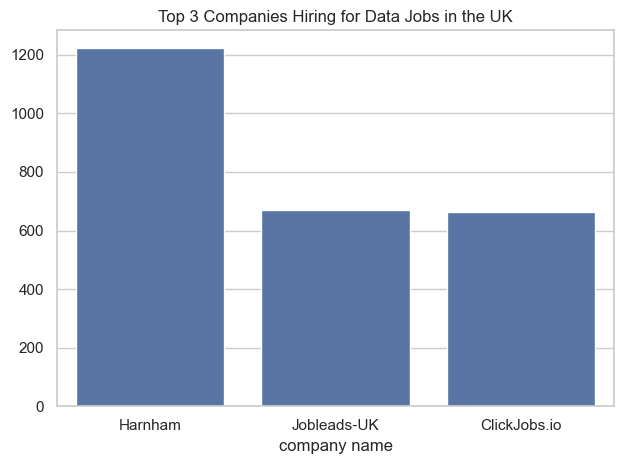

In [138]:
top_3_companies = df_companies.head(3)

sns.set_theme(style="whitegrid")

sns.barplot(
    data=top_3_companies,
    x="company_name",
    y="count",
    legend=False,
);

plt.title("Top 3 Companies Hiring for Data Jobs in the UK")
plt.xlabel("company name")
plt.ylabel("")
plt.tight_layout()

# percentage of jobs are wfh

In [32]:
df_work_from_home = df_UK.value_counts("job_work_from_home").reset_index(name="count")

df_work_from_home["total"] = df_work_from_home["count"].loc[0] + df_work_from_home["count"].loc[1]

df_work_from_home["percentage"] = (df_work_from_home["count"] / df_work_from_home["total"]) * 100

df_work_from_home

,job_work_from_home,count,total,percentage
0,False,36611,40375,90.677399
1,True,3764,40375,9.322601


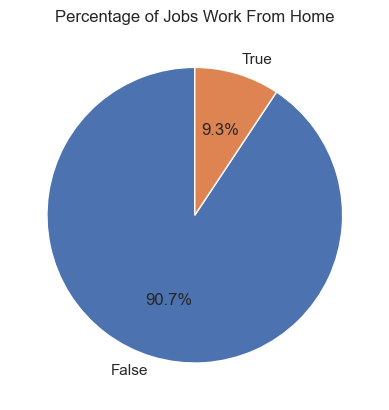

In [156]:
# Use Pandas to plot pie chart as Seaborn does not support pie charts
# Need to set index before plot because I need the labels to be column job_work_from_home
# Count column is the value of each label
df_work_from_home.set_index("job_work_from_home")["count"].plot(
    kind="pie",
    startangle=90, # Avoid 'Pacman' look
    autopct="%1.1f%%" # for formatting percentage
)

plt.title("Percentage of Jobs Work From Home");

# breakdown of the top 5 jobs

In [38]:
df_job_counts = df_UK.value_counts("job_title_short").sort_values(ascending=False).head().reset_index(name="count")

df_job_counts

,job_title_short,count
0,Data Engineer,11807
1,Data Analyst,10482
2,Data Scientist,9148
3,Senior Data Engineer,3337
4,Senior Data Scientist,2367


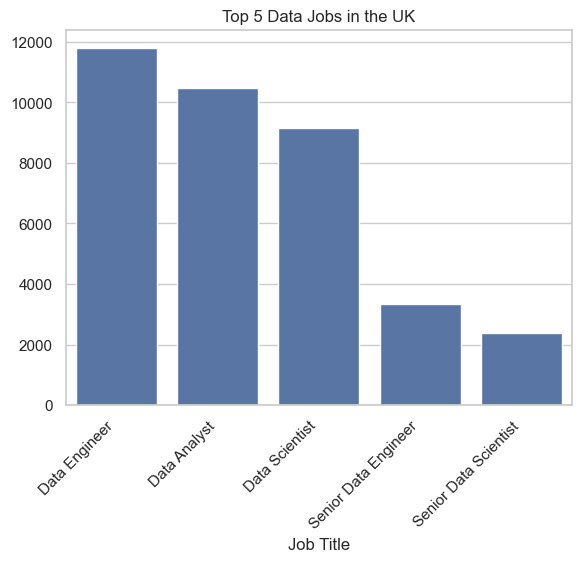

In [164]:
sns.barplot(
    data=df_job_counts,
    x="job_title_short",
    y="count",
)

plt.title("Top 5 Data Jobs in the UK")
plt.tight_layout()
plt.xlabel("Job Title")
plt.ylabel("")
plt.xticks(rotation=45, ha="right");


# salary year average of data jobs

In [ ]:
# Fill NA values in column salary_year_avg with the median salary of each job title
# Return series of median values based on job titles
job_medians = df_UK.groupby("job_title_short")["salary_year_avg"].median()

# Fill NA values with fillna method with median value based on job titles
# .transform("median") method does not work so use map with array job_medians passed through it
df_UK["salary_year_avg"] = (
    df_UK["salary_year_avg"]
    .fillna(df_UK["job_title_short"].map(job_medians))
)

In [ ]:
df_median_salaries = df_UK.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False)

df_median_salaries = df_median_salaries.reset_index(name="median_salary")

df_median_salaries

,job_title_short,median_salary
0,Senior Data Scientist,157500.0
1,Machine Learning Engineer,149653.0
2,Senior Data Engineer,147500.0
3,Senior Data Analyst,111175.0
4,Data Engineer,110000.0
5,Cloud Engineer,105300.0
6,Data Scientist,105300.0
7,Software Engineer,89100.0
8,Data Analyst,87750.0
9,Business Analyst,56700.0


# monthly demand for jobs

In [85]:
df_UK_copy = df_UK.copy()

In [87]:
# Add new column called job_posted_month
df_UK_copy["job_posted_month"] = df_UK_copy["job_posted_date"].dt.strftime("%B")

# Add a new index because it is inconsistent and give it a name
df_UK_copy.reset_index(inplace=True)
df_UK_copy.index.name = "job_index"

df_UK_copy

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
job_index,,,,,,,,,,,,,,,,,,,
0,15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,110000.0,NaN,Orion Group,"[python, sql, power bi]","{'analyst_tools': ['power bi'], 'programming':...",October
1,45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,111175.0,NaN,Corecom Consulting,"[sql, python]","{'programming': ['sql', 'python']}",May
2,74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,87750.0,NaN,ttgTalentSolutions,"[sql, r, python, tableau, power bi]","{'analyst_tools': ['tableau', 'power bi'], 'pr...",November
3,97,Data Analyst,"Systems & Data Analyst - Exploitation, Missing...",United Kingdom,via Totaljobs,Full-time and Contractor,False,United Kingdom,2023-12-04 13:14:01,True,False,United Kingdom,NaN,87750.0,NaN,Solihull Metropolitan Borough Council,None,NaN,December
4,152,Data Scientist,Data Science Team Lead,Anywhere,via OnlyDataJobs,Full-time,True,United Kingdom,2023-12-23 13:12:16,False,False,United Kingdom,NaN,105300.0,NaN,StepStone Group,"[react, docker]","{'libraries': ['react'], 'other': ['docker']}",December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40370,785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,87750.0,NaN,Viatris,"[sql, sql server, excel, powerpoint]","{'analyst_tools': ['excel', 'powerpoint'], 'da...",October
40371,785513,Data Scientist,Data Scientist,"Glasgow, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-22 06:21:21,False,False,United Kingdom,NaN,105300.0,NaN,ASA Recruitment,"[r, power bi]","{'analyst_tools': ['power bi'], 'programming':...",January
40372,785522,Data Engineer,Lead Data Engineer,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-19 06:16:45,True,False,United Kingdom,NaN,110000.0,NaN,bionic-services-ltd,"[sql, python, sql server, aws, snowflake, ssis]","{'analyst_tools': ['ssis'], 'cloud': ['aws', '...",January


In [88]:
df_UK_pivot = df_UK_copy.pivot_table(
    index="job_posted_month",
    aggfunc="size",
    columns="job_title_short"
)

df_UK_pivot.reset_index(inplace=True)

df_UK_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,April,29,7,561,611,519,8,63,155,123,18
1,August,22,7,610,863,657,15,96,247,181,13
2,December,124,31,712,1034,752,78,110,213,194,97
3,February,23,4,1051,1009,859,10,140,301,212,10
4,January,46,3,1467,1253,1142,8,169,347,326,20
5,July,38,5,892,960,646,13,116,321,184,12
6,June,14,2,736,862,636,3,102,292,154,4
7,March,47,5,712,789,699,8,91,224,179,19
8,May,23,1,614,645,486,11,60,227,153,16
9,November,155,39,840,1242,895,50,102,359,197,90


In [90]:
# PROBLEM: column job_posted_month is ordered alphabetically so data is unordered
# SOLUTION: We need a separate month number column to order this job_posted_month by
# ACTION: We add a month_no column which generates a dummy date with the same month as column job_posted_month and
#  .dt.month to extract month number from this dummy date
df_UK_pivot["month_no"] = pd.to_datetime(df_UK_pivot["job_posted_month"], format="%B").dt.month

# Data is sorted by column month_no
df_UK_pivot.sort_values("month_no", inplace=True)

df_UK_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_no
4,January,46,3,1467,1253,1142,8,169,347,326,20,1
3,February,23,4,1051,1009,859,10,140,301,212,10,2
7,March,47,5,712,789,699,8,91,224,179,19,3
0,April,29,7,561,611,519,8,63,155,123,18,4
8,May,23,1,614,645,486,11,60,227,153,16,5
6,June,14,2,736,862,636,3,102,292,154,4,6
5,July,38,5,892,960,646,13,116,321,184,12,7
1,August,22,7,610,863,657,15,96,247,181,13,8
11,September,111,32,1112,1191,898,51,139,320,221,116,9
10,October,195,57,1175,1348,959,62,168,331,243,126,10


In [91]:
# Now set column job_posted_month as a _renewed_ index
df_UK_pivot.set_index("job_posted_month", inplace=True)
# Drop column month_no as it is no longer required
df_UK_pivot.drop(columns="month_no", inplace=True)

df_UK_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,46,3,1467,1253,1142,8,169,347,326,20
February,23,4,1051,1009,859,10,140,301,212,10
March,47,5,712,789,699,8,91,224,179,19
April,29,7,561,611,519,8,63,155,123,18
May,23,1,614,645,486,11,60,227,153,16
June,14,2,736,862,636,3,102,292,154,4
July,38,5,892,960,646,13,116,321,184,12
August,22,7,610,863,657,15,96,247,181,13
September,111,32,1112,1191,898,51,139,320,221,116


In [117]:
top_3_jobs = df_UK_copy["job_title_short"].value_counts().head(3)

# Change the index of value counts output to list
# Need to do this as only list can be 
top_3_jobs = top_3_jobs.index.to_list()

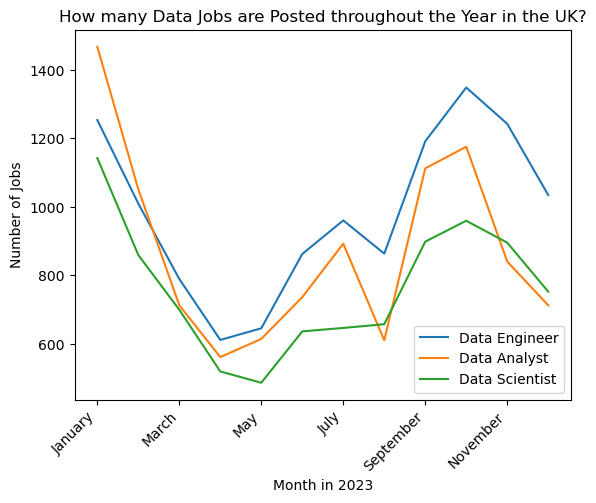

In [118]:
# Pass list of top 3 jobs into plot
df_UK_pivot[top_3_jobs].plot(
    kind="line"
);
plt.title("How many Data Jobs are Posted throughout the Year in the UK?")
plt.legend() # Gives a proper legend
plt.xlabel("Month in 2023")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right");